In [1]:
# Silence noisy logs BEFORE importing Curator / Ray / NeMo.
import logging
import os
import sys
import warnings

# Ensure the active venv's `ray` CLI is on PATH (needed for RayClient.start()).
_venv_bin = os.path.dirname(sys.executable)
if os.path.isdir(_venv_bin):
    os.environ["PATH"] = _venv_bin + os.pathsep + os.environ.get("PATH", "")

os.environ.setdefault("LOGURU_LEVEL", "ERROR")
os.environ.setdefault("NEMO_LOG_LEVEL", "ERROR")

warnings.filterwarnings("ignore", message=r".*concurrency.*deprecated.*")
warnings.filterwarnings("ignore", message=r".*num_cpus and num_gpus.*experimental.*")
logging.getLogger("nemo_logger").setLevel(logging.ERROR)

os.environ.setdefault("RAY_MAX_LIMIT_FROM_API_SERVER", "100000")


'100000'

# ALM Data Pipeline Tutorial

This notebook walks through the ALM (Audio Language Model) data pipeline:
1. Read diarized audio manifests
2. Build training windows with quality filters
3. Remove overlapping windows
4. Inspect and visualize results

**No GPU required** — all stages are CPU-only. Install with `uv sync --extra audio_cpu`.

In [2]:
import json

from nemo_curator.backends.xenna import XennaExecutor
from nemo_curator.core.client import RayClient
from nemo_curator.pipeline import Pipeline
from nemo_curator.stages.audio import ManifestReader, ManifestWriterStage
from nemo_curator.stages.audio.alm.alm_data_builder import ALMDataBuilderStage
from nemo_curator.stages.audio.alm.alm_data_overlap import ALMDataOverlapStage

## Step 1: Inspect the input data

The bundled sample has 5 audio manifest entries with diarized segments.

In [3]:
MANIFEST_PATH = os.path.join("..", "..", "..", "tests", "fixtures", "audio", "alm", "sample_input.jsonl")
OUTPUT_DIR = "./alm_tutorial_output"

with open(MANIFEST_PATH) as f:
    entries = [json.loads(line) for line in f if line.strip()]

print(f"Input entries: {len(entries)}")
for i, entry in enumerate(entries):
    n_segments = len(entry.get("segments", []))
    sr = entry.get("audio_sample_rate", "unknown")
    speakers = len({s.get("speaker", "") for s in entry.get("segments", [])})
    print(f"  [{i}] {n_segments} segments, {speakers} speakers, {sr} Hz")

Input entries: 5
  [0] 30 segments, 3 speakers, 16000 Hz
  [1] 34 segments, 2 speakers, 22050 Hz
  [2] 51 segments, 3 speakers, 16000 Hz
  [3] 36 segments, 3 speakers, 48000 Hz
  [4] 48 segments, 4 speakers, 44100 Hz


## Step 2: Run the ALM pipeline

The pipeline reads manifests, builds windows, filters overlaps, and writes output.

We run with **both** backends (Xenna and Ray Data) and compare results and timing.
Both produce identical results; wall-clock time may differ depending on data size and hardware.

In [4]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
output_path = os.path.join(OUTPUT_DIR, "alm_output.jsonl")


def build_pipeline() -> Pipeline:
    """Create a fresh pipeline instance (needed per run since the writer appends)."""
    p = Pipeline(name="alm_tutorial", description="Build ALM training windows from diarized manifests")
    p.add_stage(ManifestReader(manifest_path=MANIFEST_PATH))
    p.add_stage(
        ALMDataBuilderStage(
            target_window_duration=120.0,
            tolerance=0.1,
            min_sample_rate=16000,
            min_bandwidth=8000,
            min_speakers=2,
            max_speakers=5,
        )
    )
    p.add_stage(ALMDataOverlapStage(overlap_percentage=50))
    p.add_stage(ManifestWriterStage(output_path=output_path))
    return p


print(build_pipeline().describe())

2026-06-11 22:12:26.165 | INFO     | nemo_curator.pipeline.pipeline:add_stage:85 - Added stage 'manifest_reader' to pipeline 'alm_tutorial'


2026-06-11 22:12:26.166 | INFO     | nemo_curator.pipeline.pipeline:add_stage:85 - Added stage 'alm_data_builder' to pipeline 'alm_tutorial'


2026-06-11 22:12:26.166 | INFO     | nemo_curator.pipeline.pipeline:add_stage:85 - Added stage 'alm_data_overlap' to pipeline 'alm_tutorial'


2026-06-11 22:12:26.166 | INFO     | nemo_curator.pipeline.pipeline:add_stage:85 - Added stage 'manifest_writer' to pipeline 'alm_tutorial'


Pipeline: alm_tutorial
Description: Build ALM training windows from diarized manifests
Stages: 4

Stage 1: manifest_reader
  Resources: 1.0 CPUs
  Batch size: 1
Stage 2: alm_data_builder
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: audio_filepath, segments, audio_sample_rate
Stage 3: alm_data_overlap
  Resources: 1.0 CPUs
  Batch size: 1
  Inputs:
    Required columns: windows
Stage 4: manifest_writer
  Resources: 1.0 CPUs
  Batch size: 1



In [5]:
import time

from nemo_curator.backends.ray_data import RayDataExecutor

ray_client = RayClient()
ray_client.start()

backends = {
    "xenna": XennaExecutor,
    "ray_data": RayDataExecutor,
}

run_results = {}

for name, executor_cls in backends.items():
    if os.path.exists(output_path):
        os.remove(output_path)

    pipeline = build_pipeline()
    executor = executor_cls()

    t0 = time.time()
    pipeline.run(executor)
    elapsed = time.time() - t0

    with open(output_path) as f:
        data = [json.loads(line) for line in f if line.strip()]

    total_windows = sum(len(r.get("filtered_windows", [])) for r in data)
    total_dur = sum(r.get("filtered_dur", 0) for r in data)

    run_results[name] = {
        "time": elapsed,
        "entries": len(data),
        "windows": total_windows,
        "duration": total_dur,
        "data": data,
    }
    print(f"[{name}] {elapsed:.2f}s — {len(data)} entries, {total_windows} windows, {total_dur:.1f}s audio")

2026-06-11 22:12:26.278 | WARNING  | nemo_curator.core.client:start:121 - No monitoring services are running. Please run the `start_prometheus_grafana.py` script from nemo_curator/metrics folder to setup monitoring services separately.


2026-06-11 22:12:26.281 | INFO     | nemo_curator.core.utils:init_cluster:212 - Ray start command: ray start --head --node-ip-address 127.0.1.1 --port 6379 --metrics-export-port 8080 --dashboard-host 127.0.0.1 --dashboard-port 8265 --ray-client-server-port 10001 --temp-dir /tmp/ray --disable-usage-stats --block


2026-06-11 22:12:27,523	INFO usage_lib.py:448 -- Usage stats collection is disabled.
2026-06-11 22:12:27,523	INFO scripts.py:940 -- Local node IP: 127.0.1.1
2026-06-11 22:12:33,584	SUCC scripts.py:979 -- --------------------
2026-06-11 22:12:33,584	SUCC scripts.py:980 -- Ray runtime started.
2026-06-11 22:12:33,584	SUCC scripts.py:981 -- --------------------
2026-06-11 22:12:33,584	INFO scripts.py:983 -- Next steps
2026-06-11 22:12:33,584	INFO scripts.py:986 -- To add another node to this Ray cluster, run
2026-06-11 22:12:33,584	INFO scripts.py:989 --   ray start --address='127.0.1.1:6379'
2026-06-11 22:12:33,584	INFO scripts.py:1000 -- To connect to this Ray cluster:
2026-06-11 22:12:33,584	INFO scripts.py:1002 -- import ray
2026-06-11 22:12:33,584	INFO scripts.py:1003 -- ray.init(_node_ip_address='127.0.1.1')
2026-06-11 22:12:33,584	INFO scripts.py:1017 -- To submit a Ray job using the Ray Jobs CLI:
2026-06-11 22:12:33,584	INFO scripts.py:1018 --   RAY_API_SERVER_ADDRESS='http://127.

2026-06-11 22:12:36.436 | INFO     | nemo_curator.pipeline.pipeline:add_stage:85 - Added stage 'manifest_reader' to pipeline 'alm_tutorial'


2026-06-11 22:12:36.437 | INFO     | nemo_curator.pipeline.pipeline:add_stage:85 - Added stage 'alm_data_builder' to pipeline 'alm_tutorial'


...

(MapBatches(FilePartitioningStageTask) pid=746159) 2026-06-11 22:13:14.989 | INFO     | nemo_curator.stages.file_partitioning:process:120 - Found 1 files
(MapBatches(FilePartitioningStageTask) pid=746159) 2026-06-11 22:13:14.989 | INFO     | nemo_curator.stages.file_partitioning:process:189 - Created 1 file groups from 1 files


(MapBatches(ManifestReaderStageTask)->StreamingRepartition[num_rows_per_block=1,strict=False] pid=746159) 2026-06-11 22:13:15.146 | INFO     | nemo_curator.stages.audio.common:process:164 - ManifestReaderStage: loaded 5 entries from /home/aaftabv/grananary-v2/references/CuratorPRReviews/tutorials/audio/alm/../../../tests/fixtures/audio/alm/sample_input.jsonl


(MapWorker(MapBatches(ALMDataBuilderStageTask)->MapBatches(ALMDataOverlapStageTask)->MapBatches(ManifestWriterStageActor)) pid=746459) 2026-06-11 22:13:17.687 | INFO     | nemo_curator.stages.audio.common:setup:267 - ManifestWriterStage: writing to ./alm_tutorial_output/alm_output.jsonl
2026-06-11 22:13:17,765	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_7_0 execution finished in 5.89 seconds


2026-06-11 22:13:17.770 | INFO     | nemo_curator.backends.ray_data.executor:execute:98 - Pipeline completed. Final results: 5 tasks


[ray_data] 14.57s — 5 entries, 25 windows, 3035.5s audio


In [6]:
MATCH_TOL = 0.1

print("\n" + "=" * 60)
print("Backend Comparison")
print("=" * 60)
print(f"{'':>12s}  {'Xenna':>10s}  {'Ray Data':>10s}  {'Match':>6s}")
print(f"{'Time (s)':>12s}  {run_results['xenna']['time']:10.2f}  {run_results['ray_data']['time']:10.2f}  {'':>6s}")
print(
    f"{'Entries':>12s}  {run_results['xenna']['entries']:10d}  {run_results['ray_data']['entries']:10d}"
    f"  {'✓' if run_results['xenna']['entries'] == run_results['ray_data']['entries'] else '✗':>6s}"
)
print(
    f"{'Windows':>12s}  {run_results['xenna']['windows']:10d}  {run_results['ray_data']['windows']:10d}"
    f"  {'✓' if run_results['xenna']['windows'] == run_results['ray_data']['windows'] else '✗':>6s}"
)
print(
    f"{'Audio (s)':>12s}  {run_results['xenna']['duration']:10.1f}  {run_results['ray_data']['duration']:10.1f}"
    f"  {'✓' if abs(run_results['xenna']['duration'] - run_results['ray_data']['duration']) < MATCH_TOL else '✗':>6s}"
)
speedup = run_results["ray_data"]["time"] / run_results["xenna"]["time"]
faster = "xenna" if speedup > 1 else "ray_data"
print(f"\n→ {faster} was {max(speedup, 1 / speedup):.1f}x faster on this dataset")

results = run_results["xenna"]["data"]


Backend Comparison
                   Xenna    Ray Data   Match
    Time (s)       27.02       14.57        
     Entries           5           5       ✓
     Windows          25          25       ✓
   Audio (s)      3035.5      3035.5       ✓

→ ray_data was 1.9x faster on this dataset


## Step 3: Inspect results

In [7]:
print(f"Output entries: {len(results)}")

total_windows_before = sum(len(r.get("windows", [])) for r in results)
total_windows_after = sum(len(r.get("filtered_windows", [])) for r in results)
total_duration = sum(r.get("filtered_dur", 0) for r in results)

print(f"Windows before overlap filter: {total_windows_before}")
print(f"Windows after overlap filter:  {total_windows_after}")
print(f"Total filtered audio duration: {total_duration:.1f}s ({total_duration / 3600:.2f}h)")
print(
    f"Overlap reduction: {(1 - total_windows_after / total_windows_before) * 100:.0f}%"
    if total_windows_before
    else "N/A"
)

Output entries: 5
Windows before overlap filter: 181
Windows after overlap filter:  25
Total filtered audio duration: 3035.5s (0.84h)
Overlap reduction: 86%


## Step 4: Understand the filtering statistics

In [8]:
for i, r in enumerate(results):
    stats = r.get("stats", {})
    print(f"Entry [{i}]:")
    print(f"  Total segments: {stats.get('total_segments', 'N/A')}")
    print(f"  Total duration: {stats.get('total_dur', 0):.1f}s")
    print(f"  Lost (low bandwidth):    {stats.get('lost_bw', 0)}")
    print(f"  Lost (low sample rate):  {stats.get('lost_sr', 0)}")
    print(f"  Lost (speaker count):    {stats.get('lost_spk', 0)}")
    print(f"  Lost (window constraints): {stats.get('lost_win', 0)}")
    print(f"  Truncation events: {r.get('truncation_events', 0)}")
    print()

Entry [0]:
  Total segments: 30
  Total duration: 129.3s
  Lost (low bandwidth):    0
  Lost (low sample rate):  0
  Lost (speaker count):    0
  Lost (window constraints): 2
  Truncation events: 11

Entry [1]:
  Total segments: 34
  Total duration: 149.2s
  Lost (low bandwidth):    0
  Lost (low sample rate):  0
  Lost (speaker count):    0
  Lost (window constraints): 4
  Truncation events: 15

Entry [2]:
  Total segments: 36
  Total duration: 159.6s
  Lost (low bandwidth):    0
  Lost (low sample rate):  0
  Lost (speaker count):    0
  Lost (window constraints): 3
  Truncation events: 16

Entry [3]:
  Total segments: 51
  Total duration: 212.4s
  Lost (low bandwidth):    0
  Lost (low sample rate):  0
  Lost (speaker count):    0
  Lost (window constraints): 5
  Truncation events: 24

Entry [4]:
  Total segments: 48
  Total duration: 197.8s
  Lost (low bandwidth):    0
  Lost (low sample rate):  0
  Lost (speaker count):    0
  Lost (window constraints): 4
  Truncation events: 26



## Step 5: Visualize results

### Window duration distribution and filter effects

2026-06-11 22:13:18,532 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-11 22:13:18,532 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


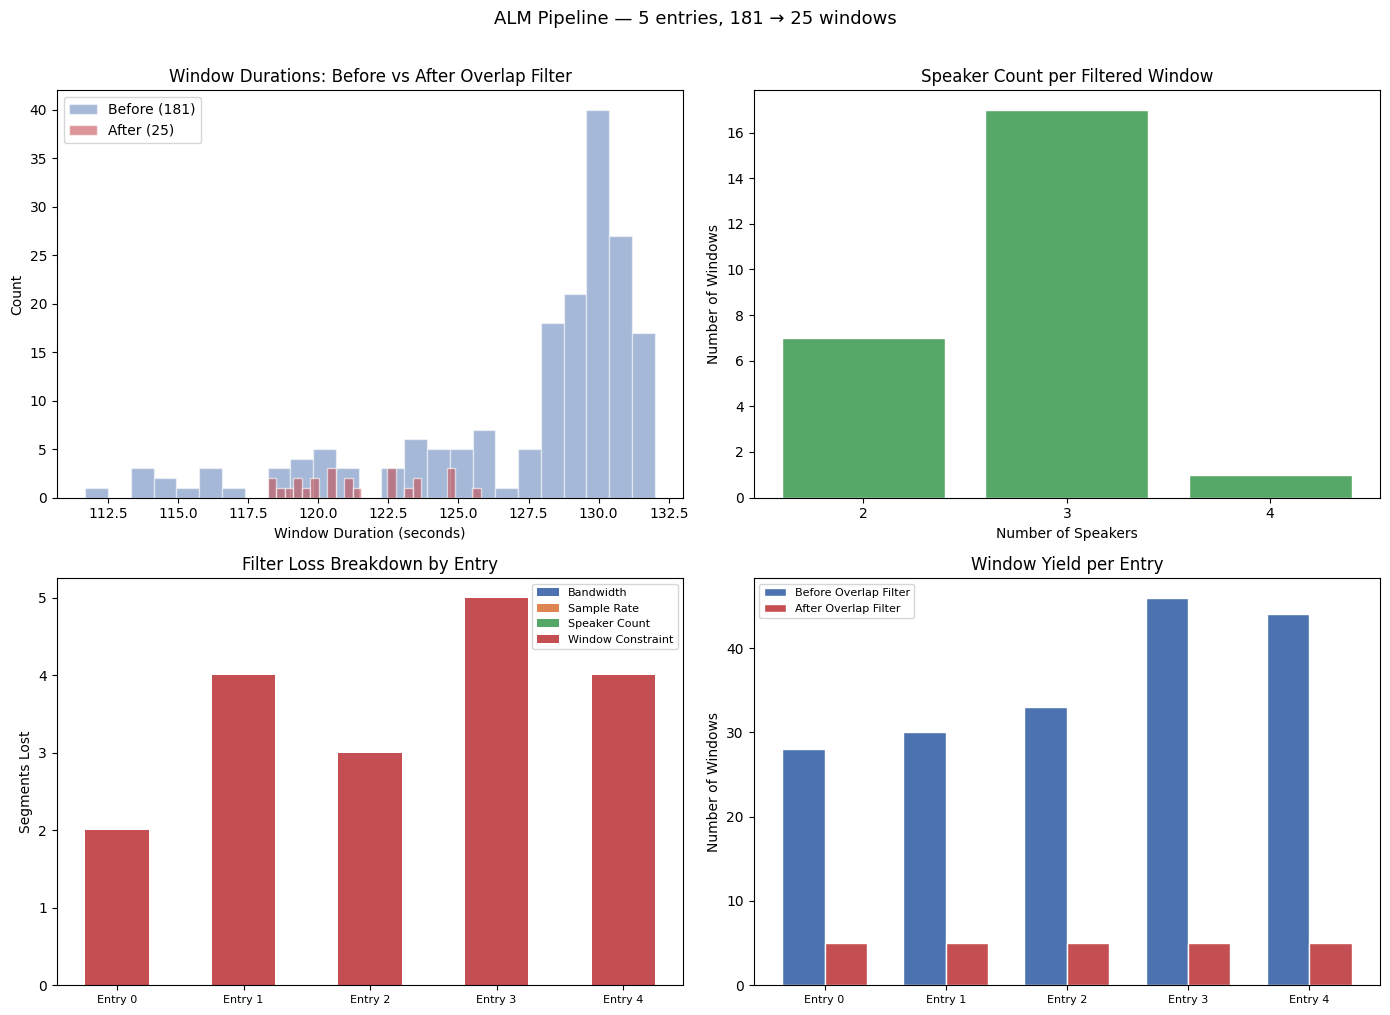


Filtered durations — min: 118.2s, max: 125.8s, mean: 121.4s


In [9]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Collect data from results
all_win_durs = []
all_filt_durs = []
for r in results:
    for w in r.get("windows", []):
        segs = w.get("segments", [])
        if segs:
            dur = segs[-1].get("end", 0) - segs[0].get("start", 0)
            all_win_durs.append(dur)
    all_filt_durs.extend(r.get("filtered_dur_list", []))

# 1. Window duration histogram — before vs after overlap filter
ax = axes[0, 0]
if all_win_durs:
    ax.hist(
        all_win_durs, bins=25, color="#4C72B0", alpha=0.5, label=f"Before ({len(all_win_durs)})", edgecolor="white"
    )
if all_filt_durs:
    ax.hist(
        all_filt_durs, bins=25, color="#C44E52", alpha=0.6, label=f"After ({len(all_filt_durs)})", edgecolor="white"
    )
ax.set_xlabel("Window Duration (seconds)")
ax.set_ylabel("Count")
ax.set_title("Window Durations: Before vs After Overlap Filter")
ax.legend()

# 2. Speaker count distribution across filtered windows
ax = axes[0, 1]
speaker_counts = []
for r in results:
    for fw in r.get("filtered_windows", []):
        speakers = {s.get("speaker", "") for s in fw.get("segments", [])}
        speaker_counts.append(len(speakers))
if speaker_counts:
    counts = Counter(speaker_counts)
    labels = sorted(counts.keys())
    ax.bar([str(k) for k in labels], [counts[k] for k in labels], color="#55A868", edgecolor="white")
ax.set_xlabel("Number of Speakers")
ax.set_ylabel("Number of Windows")
ax.set_title("Speaker Count per Filtered Window")

# 3. Filter loss breakdown — stacked bar per entry
ax = axes[1, 0]
entry_labels = [f"Entry {i}" for i in range(len(results))]
loss_bw = [r.get("stats", {}).get("lost_bw", 0) for r in results]
loss_sr = [r.get("stats", {}).get("lost_sr", 0) for r in results]
loss_spk = [r.get("stats", {}).get("lost_spk", 0) for r in results]
loss_win = [r.get("stats", {}).get("lost_win", 0) for r in results]
x = np.arange(len(results))
w = 0.5
ax.bar(x, loss_bw, w, label="Bandwidth", color="#4C72B0")
ax.bar(x, loss_sr, w, bottom=loss_bw, label="Sample Rate", color="#DD8452")
bottoms = [a + b for a, b in zip(loss_bw, loss_sr, strict=True)]
ax.bar(x, loss_spk, w, bottom=bottoms, label="Speaker Count", color="#55A868")
bottoms2 = [a + b for a, b in zip(bottoms, loss_spk, strict=True)]
ax.bar(x, loss_win, w, bottom=bottoms2, label="Window Constraint", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(entry_labels, fontsize=8)
ax.set_ylabel("Segments Lost")
ax.set_title("Filter Loss Breakdown by Entry")
ax.legend(fontsize=8)

# 4. Per-entry window yield — before vs after
ax = axes[1, 1]
wins_before = [len(r.get("windows", [])) for r in results]
wins_after = [len(r.get("filtered_windows", [])) for r in results]
x = np.arange(len(results))
w = 0.35
ax.bar(x - w / 2, wins_before, w, label="Before Overlap Filter", color="#4C72B0", edgecolor="white")
ax.bar(x + w / 2, wins_after, w, label="After Overlap Filter", color="#C44E52", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(entry_labels, fontsize=8)
ax.set_ylabel("Number of Windows")
ax.set_title("Window Yield per Entry")
ax.legend(fontsize=8)

fig.suptitle(
    f"ALM Pipeline — {len(results)} entries, {sum(wins_before)} → {sum(wins_after)} windows", fontsize=13, y=1.01
)
fig.tight_layout()
plt.show()

print(
    f"\nFiltered durations — min: {min(all_filt_durs):.1f}s, max: {max(all_filt_durs):.1f}s, "
    f"mean: {np.mean(all_filt_durs):.1f}s"
    if all_filt_durs
    else "No filtered windows."
)

## Step 6: Experiment with parameters

Try different overlap thresholds and see how they affect the output:

In [10]:
from nemo_curator.tasks.audio_task import AudioTask

sample_entry = entries[0]
task = AudioTask(data=sample_entry)

builder = ALMDataBuilderStage(
    target_window_duration=120.0,
    tolerance=0.1,
    min_sample_rate=16000,
    min_bandwidth=8000,
    min_speakers=2,
    max_speakers=5,
)
built = builder.process(task)
n_windows = len(built.data.get("windows", []))

print(f"Windows from entry[0]: {n_windows}")
print()

for pct in [0, 25, 50, 75, 100]:
    overlap = ALMDataOverlapStage(overlap_percentage=pct)
    filtered = overlap.process(built)
    n_filtered = len(filtered.data.get("filtered_windows", []))
    print(
        f"  overlap_percentage={pct:3d}: {n_filtered:3d} windows kept ({n_filtered / n_windows * 100:.0f}%)"
        if n_windows
        else "  No windows"
    )

Windows from entry[0]: 28

  overlap_percentage=  0:   3 windows kept (11%)
  overlap_percentage= 25:   5 windows kept (18%)
  overlap_percentage= 50:   5 windows kept (18%)
  overlap_percentage= 75:   5 windows kept (18%)
  overlap_percentage=100:  17 windows kept (61%)


## Cleanup

Shut down the Ray cluster started by `RayClient`.

In [11]:
ray_client.stop()

2026-06-11 22:13:22.141 | INFO     | nemo_curator.core.client:stop:205 - NeMo Curator has stopped the Ray cluster it started by killing the Ray GCS process. It is advised to wait for a few seconds before running any Ray commands to ensure Ray can cleanup other processes.If you are seeing any Ray commands like `ray status` failing, please ensure /tmp/ray/ray_current_cluster has correct information.
